<a href="https://colab.research.google.com/github/layangamil/ml-lab-course/blob/main/labb4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
#Task 1.0 - importing libraries - preparation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [6]:
#Task 1.1 - Data Acquisition - Load MNIST dataset (70,000 images), flatten each 28x28 image to 784 features.

import numpy as np
import keras
from keras.datasets import mnist as keras_mnist


(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate((X_train_raw, X_test_raw), axis=0).reshape(-1, 28 * 28)
y = np.concatenate((y_train_raw, y_test_raw), axis=0).astype(str)


#Data Acquisition. Purpose: Create wrapper object to mimic fetch_openml structure.

class MNISTData:
    def __init__(self, data, target):
        self.data = data
        self.target = target
        self.DESCR = "MNIST dataset loaded via Keras workaround."
    def keys(self):
        return ['data', 'target', 'DESCR']

# Create the object the rest of the lab is looking for
mnist = MNISTData(X, y)

print("Workaround complete. Data loaded successfully!")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Workaround complete. Data loaded successfully!


In [7]:
print(mnist.DESCR)

MNIST dataset loaded via Keras workaround.


In [8]:
mnist.keys()  #we only use data and target in this notebook

['data', 'target', 'DESCR']

In [9]:
X, y = mnist.data, mnist.target
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [10]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype='<U3')

In [11]:
#task 1.2 - Shape Verification. Should output (70000, 784) (70000,) - verifies 70,000 images with 784 features each

# Display the shape of the data and labels
print(X.shape, y.shape)

(70000, 784) (70000,)


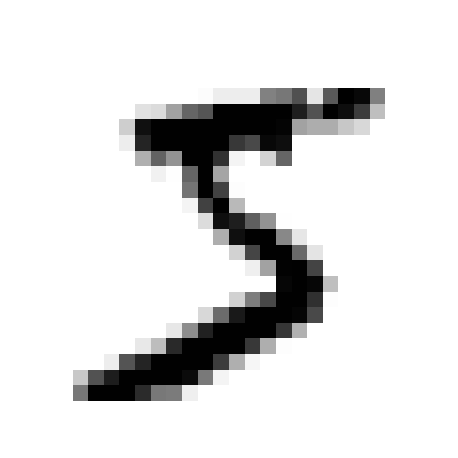

In [12]:
#Task 1.3 - Visualization Function. Create plot_digit() function that reshapes 784 features to 28x28 and displays it. Tests on first digit.

import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # to get a grayscale color map where 0 is white and 255 is black
    plt.axis("off")

some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()

In [13]:
print("The first digit in the Data set is: ", y[0]) # check in the label dataset

The first digit in the Data set is:  5


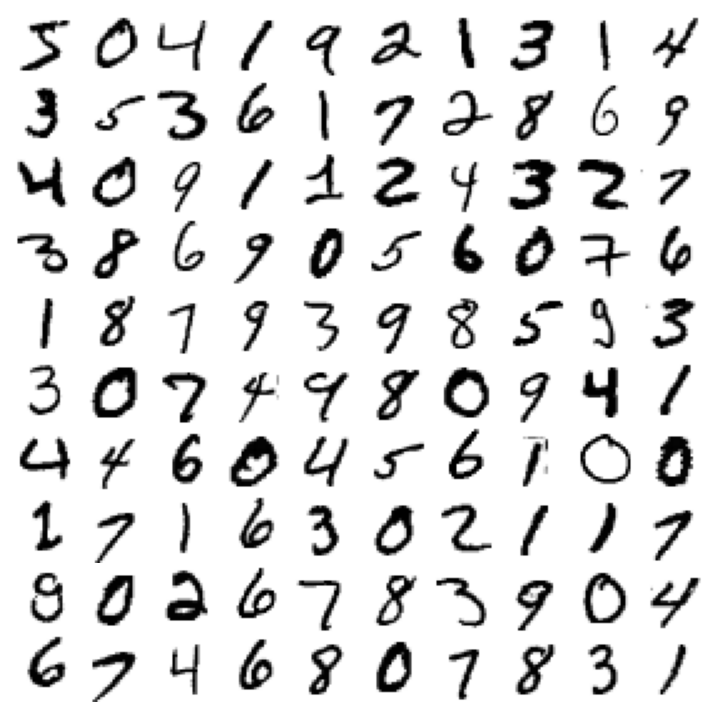

In [14]:
# This cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

In [15]:
#Task 1.4 - Data Splitting
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [16]:
#arget Definition (binary classifier preparation) - Purpose: Create binary target vectors for "5-detector" - True for all 5s, False for all other digits
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [17]:
#TASK 2: Training a Binary Classifier. - Initialize SGDClassifier (efficient for large datasets because it processes one instance at a time) and train on binary 5-detection task

# Import the SGDClassifier from Scikit-Learn's linear model module
from sklearn.linear_model import SGDClassifier

# Create an instance of the SGDClassifier with a specified random state for reproducibility
# The random state ensures that the results are consistent across different runs
sgd_clf = SGDClassifier(random_state=42)


# Fit the SGDClassifier to the training data
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
sgd_clf.fit(X_train, y_train_5)


SGDClassifier(random_state=42)

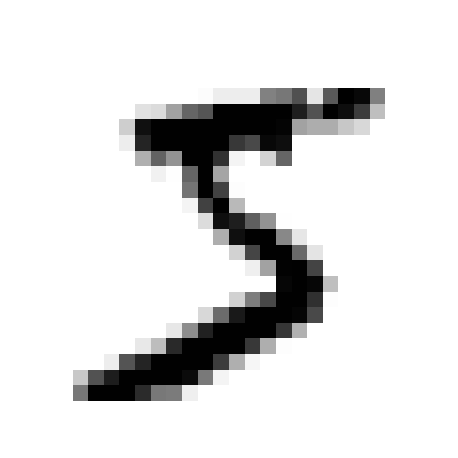

In [18]:
#Task 2.3 - Prediction - Display first digit to see what we're predicting

some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

In [19]:
sgd_clf.predict([some_digit])

array([ True])

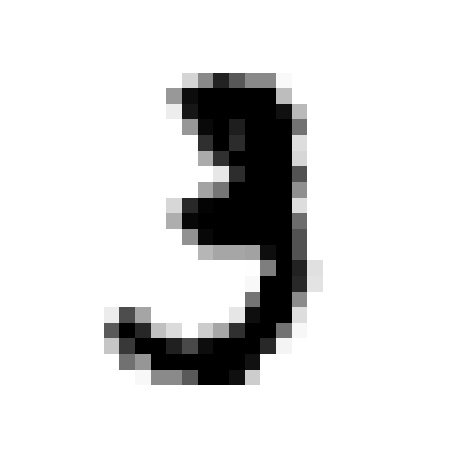

In [20]:
some_digit = X[10]  # display 10th digit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

In [21]:
sgd_clf.predict([some_digit])

array([False])

In [22]:
#Predict on first 5 digits at once, showing array of predictions

# Examples of digits from the dataset
some_digits = X[:5]

# Make predictions on the multiple examples
predictions = sgd_clf.predict(some_digits)

# Display the predictions
print("Predictions for some_digits:", predictions)

Predictions for some_digits: [ True False False False False]


In [23]:
#Task 3 Preview (Cross-Validation - Not yet Task 2)
from sklearn.model_selection import cross_val_score # Import the cross_val_score function from Scikit-Learn


# Perform 3-fold cross-validation on the SGD classifier
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="accuracy"' specifies that we want to calculate the accuracy score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# Display the cross-validation accuracy scores
#print("Cross-validation accuracy:", cross_val_score)

array([0.95035, 0.96035, 0.9604 ])

In [24]:
#Task 3.1 - Cross-Validation - Manually implements 3-fold stratified cross-validation to evaluate accuracy. StratifiedKFold preserves percentage of 5s in each fold.
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))


0.95035
0.96035
0.9604


In [25]:
#Task 3.1 - Cross-Validation (baseline comparison)- Creates a DummyClassifier (always predicts the most frequent class - "not 5") to show why accuracy alone is misleading.

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # it prints False: which means no 5s detected


False


In [26]:
#Task 3.1 - Cross-Validation (scikit-learn version) -  Uses cross_val_score to evaluate dummy classifier. Will show ~90% accuracy despite being useless.
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [27]:
#Task 3.2 - Confusion Matrix (get predictions) - Unlike cross_val_score which returns accuracy scores, cross_val_predict returns the actual predictions made during cross-validation (each instance predicted by a model that never saw it during training).

# Import cross_val_predict function from Scikit-Learn
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions for the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [28]:
#Task 3.2 - Confusion Matrix (compute matrix) - Creates confusion matrix comparing actual labels (y_train_5) with predicted labels (y_train_pred).

# Import confusion_matrix function from Scikit-Learn
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix to evaluate the classifier's performance
# 'y_train_5' are the actual labels
# 'y_train_pred' are the predicted labels from cross-validation
cm = confusion_matrix(y_train_5, y_train_pred)
#cm

In [29]:
print(cm)

[[53892   687]
 [ 1891  3530]]


In [30]:
#Task 3.2 - Confusion Matrix (perfect scenario demonstration) - Shows what confusion matrix looks like with perfect predictions - diagonal only, zeros elsewhere.

# Pretend we reached perfection by setting the predicted labels equal to the true labels
y_train_perfect_predictions = y_train_5

# Compute the confusion matrix with perfect predictions
# The confusion matrix should show all true positives and true negatives, with no false positives or false negatives
confusion_matrix(y_train_5, y_train_perfect_predictions)


array([[54579,     0],
       [    0,  5421]])

In [31]:
#Task 4.1 - Precision - Calculates precision = TP/(TP+FP). Answers: "When classifier predicts 5, how often is it correct?"

# Import precision_score and recall_score from Scikit-Learn
from sklearn.metrics import precision_score, recall_score


# Compute the precision score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
precision = precision_score(y_train_5, y_train_pred)  # # Calculate precision: TP / (FP + TP) that is == 3530 / (687 + 3530)
print("Precision:", precision)

Precision: 0.8370879772350012


In [32]:
#Task 4.1 - Precision (manual verification) - Shows how to extract precision directly from confusion matrix: TP/(FP+TP).

precision_manual = cm[1, 1] / (cm[0, 1] + cm[1, 1])
print("Manual precision calculation:", precision_manual) # manual precision calucltion from the confusion matrix

Manual precision calculation: 0.8370879772350012


In [33]:
#Task 4.1 - Recall  - Calculates recall = TP/(TP+FN). Answers: "How many actual 5s did we find?"

recall = recall_score(y_train_5, y_train_pred)  # Calculate recall: TP / (FN + TP)
print("Recall:", recall)

Recall: 0.6511713705958311


In [34]:
# Task 4.1 - Recall (manual verification) - Shows recall from confusion matrix: TP/(FN+TP).
recall_manual = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print("Manual recall calculation:", recall_manual) # manual recall calucltion from the confusion matrix


Manual recall calculation: 0.6511713705958311


In [35]:
#Task 4.1 - F1 Score - Calculates F1 = harmonic mean of precision and recall = 2 * (precision * recall)/(precision + recall). Balances both metrics.

from sklearn.metrics import f1_score


f1 = f1_score(y_train_5, y_train_pred)  # Calculate the F1 Score using the precision and recall
print("F1 Score:", f1)


F1 Score: 0.7325171197343847


In [36]:

# To compute the F1 Score manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN, 'cm[0, 1]' is FP
# extra code – this cell also computes the f1 score
f1_manual = cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)
print("Manual F1 Score calculation:", f1_manual)

Manual F1 Score calculation: 0.7325171197343847


In [37]:
#Task 4.1 - Complete metrics summary - classification_report displays precision, recall, f1-score, and support (number of instances) for each class in one table.

from sklearn.metrics import classification_report

# Confusion Matrix
print("Confusion Matrix:")
print(cm)

# Classification Report
class_report = classification_report(y_train_5, y_train_pred)
print("Classification Report:")
print(class_report)

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



In [38]:
#Task 4.2 - Threshold Analysis:


some_digit = X[0] # check for 1st didgit in the dataset, please feel free to check for other digits as well

y_scores = sgd_clf.decision_function([some_digit]) #
print("Decision Scores:", y_scores)

Decision Scores: [2164.22030239]


In [39]:
# Threshold Analysis (default threshold)
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print("Digit prediction based on Decision Score threshold:", y_some_digit_pred)


Digit prediction based on Decision Score threshold: [ True]


In [40]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [41]:
#Threshold Analysis (get all scores) - Gets decision scores for ALL training instances via cross-validation (unlike earlier predict which gave binary labels).
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

# 'y_scores' will contain the decision scores for each instance in the training set
print(y_scores)

[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


In [42]:
#Task 4.2 - Precision/Recall Curve - Computes precision and recall at EVERY possible threshold value. Returns arrays to visualize trade-off.

from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)


In [43]:
 #Shows current threshold value (3000 from earlier).

print("Current Threshold is set:", threshold)

Current Threshold is set: 3000


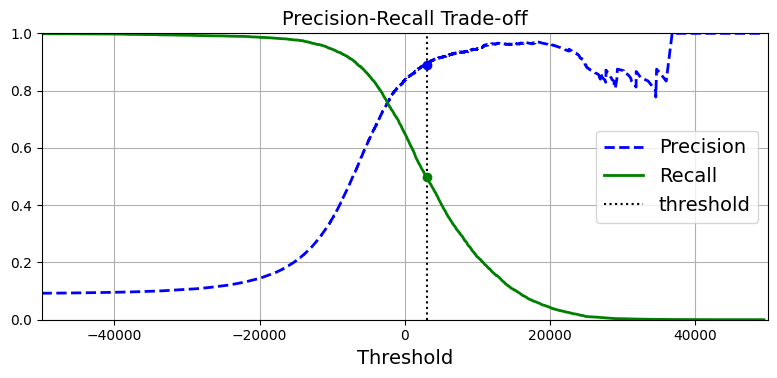

In [44]:
#Task 4.2 - Precision/Recall vs Threshold Plot - Plots how precision and recall change as threshold increases.

plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

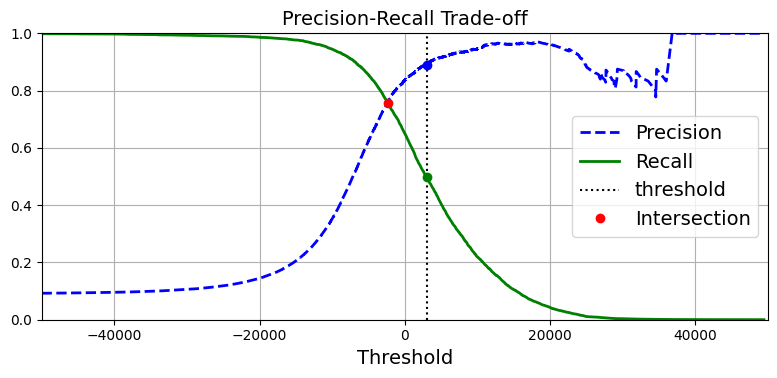

In [45]:
# Highlight the Intersection Point of Precision and Recall


# Find the index where precision and recall are closest to each other
diff = np.abs(precisions - recalls)
min_diff_index = np.argmin(diff)


plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.plot(thresholds[min_diff_index], precisions[min_diff_index], "ro", label="Intersection") # Highlight the intersection point
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

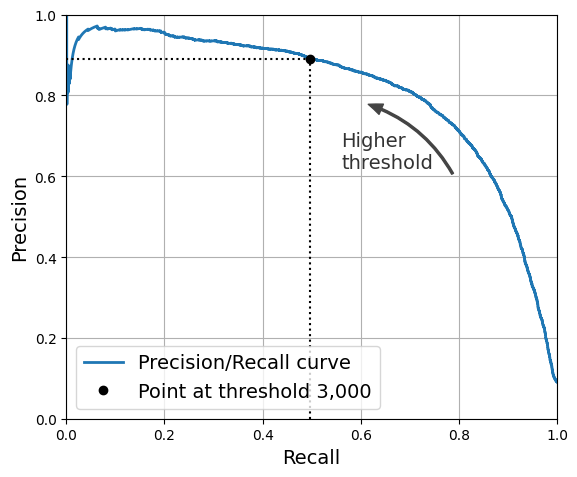

In [46]:
#Task 4.2 - Precision vs Recall Curve - Plots precision directly against recall (no threshold axis). This is the PR curve - shows trade-off clearly.

import matplotlib.patches as patches  # For the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()


In [47]:
#Finds the lowest threshold that achieves at least 90% precision.

indices_above_90 = np.where(precisions[:len(thresholds)] >= 0.90)[0]

if len(indices_above_90) > 0:
    # Get the first index where precision is >= 0.90
    idx_for_90_precision = indices_above_90[0]
else:
    # If no precision >= 0.90 is found, select the last valid index
    # This is a fallback to prevent IndexError if no threshold meets the criteria
    idx_for_90_precision = len(thresholds) - 1

# Ensure the index is within bounds, especially for edge cases
idx_for_90_precision = min(idx_for_90_precision, len(thresholds) - 1)
idx_for_90_precision = max(idx_for_90_precision, 0)

threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision


np.float64(3370.0194991439557)

In [48]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [49]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [50]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

In [51]:
#Task 4.3 - ROC Curve - Computes False Positive Rate (FPR) and True Positive Rate (TPR = recall) at all thresholds for ROC curve.

from sklearn.metrics import roc_curve # Import roc_curve function from Scikit-Learn

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

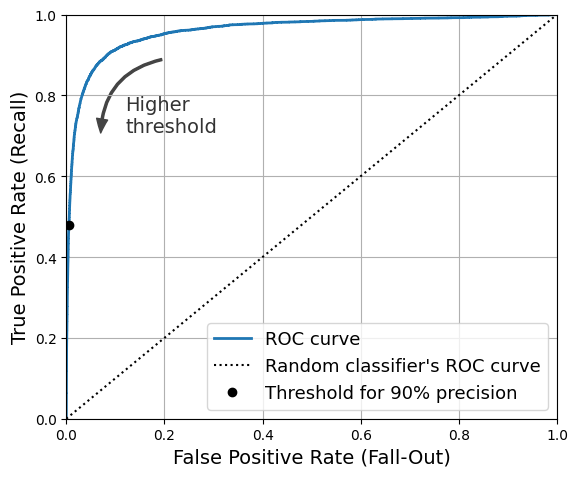

In [52]:
#Plots ROC curve with diagonal line showing random classifier (AUC=0.5). Adds dot for 90% precision threshold.

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

In [53]:
#Calculates Area Under the ROC Curve. Higher is better (1.0 = perfect, 0.5 = random).

from sklearn.metrics import roc_auc_score # Import the roc_auc_score function from Scikit-Learn

# Calculate the AUC-ROC score
auc_roc= roc_auc_score(y_train_5, y_scores)

# Display the AUC-ROC score
print("AUC-ROC Score:", auc_roc)

AUC-ROC Score: 0.9604938554008616


In [54]:
#Task 5.1 - Ensemble Training (initialization) - Creates Random Forest classifier (ensemble of decision trees).

from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier from Scikit-Learn

# Create an instance of the Random Forest Classifier
forest_clf = RandomForestClassifier(random_state=42)

In [56]:
#Task 5.1 - Ensemble Training (cross-validation predictions) - Purpose: Gets probability predictions (not decision scores) from Random Forest. Each prediction is [prob(not 5), prob(is 5)].

# Perform cross-validation to obtain probability predictions for each instance in the training set
# 'forest_clf' is the Random Forest classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="predict_proba"' specifies that we want to get the probability predictions instead of class labels
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [57]:
# Display the first two probability predictions
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [58]:
#Task 5.2 - Evaluation (PR curve for Random Forest) - Purpose: Extracts probability of being a 5 (column index 1) and computes precision/recall curve.
y_scores_forest = y_probas_forest[:, 1]

# Calculate precision and recall for different threshold values
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

In [59]:

print("Precision Forest=", precisions_forest)
print("Recall Forest=", recalls_forest)
print("Threshold Forest=", thresholds_forest)

Precision Forest= [0.09035    0.15601796 0.21697018 0.2782198  0.3359375  0.39168474
 0.4434341  0.49221099 0.53883011 0.58103448 0.62384152 0.65814579
 0.69354839 0.72090213 0.74856904 0.77310803 0.79370733 0.81468478
 0.83029737 0.84566529 0.8605178  0.87232994 0.88209825 0.89121268
 0.90208833 0.90986159 0.9178634  0.92464178 0.93120086 0.93672255
 0.94127273 0.94605505 0.95223107 0.95618941 0.95927941 0.96257089
 0.96431961 0.96689629 0.96939365 0.97113522 0.97292032 0.975495
 0.97634069 0.9787572  0.98101519 0.98323571 0.98412375 0.98566455
 0.98719273 0.98773389 0.98974681 0.99050833 0.99129327 0.99186644
 0.99180858 0.99259582 0.99340804 0.99378606 0.99440841 0.99458239
 0.99474526 0.99514451 0.99555659 0.99622997 0.99618594 0.99638031
 0.9965661  0.99652605 0.99672462 0.99692938 0.99688393 0.99762031
 0.9981203  0.99809004 0.99832496 0.99828816 0.99825581 0.99821694
 0.99847793 0.99843309 0.99903038 0.99900498 0.99897119 0.99893692
 0.9989011  0.9996173  1.         1.         1

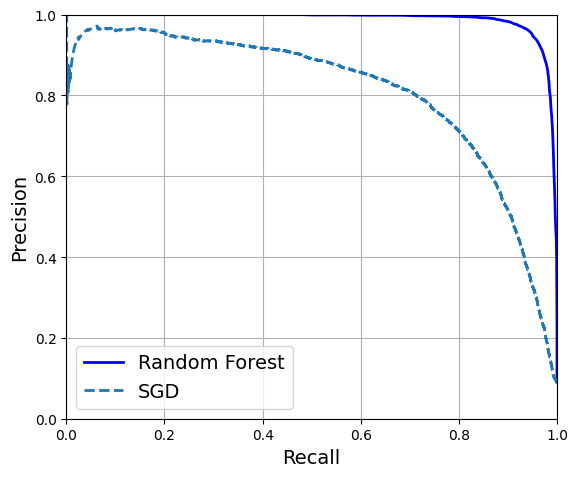

In [60]:
#Task 5.2 - Comparison Plot - Overlays PR curves for Random Forest and SGD for direct comparison.
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

In [61]:
#Converts probabilities to binary predictions (threshold=0.5) and computes F1 score for comparison with SGD.
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [62]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

In [63]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [64]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [65]:
#For class report

# Classification Report SGD
#class_report_SGD = classification_report(y_train_5, y_train_pred)
#print("Classification Report of SGD:")
#print(class_report_SGD)


# Classification Report SGD
class_report_forest = classification_report(y_train_5, y_train_pred_forest)
print("Classification Report of Random Fdrest:")
print(class_report_forest)

Classification Report of Random Fdrest:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99     54579
        True       0.99      0.87      0.93      5421

    accuracy                           0.99     60000
   macro avg       0.99      0.94      0.96     60000
weighted avg       0.99      0.99      0.99     60000

